<a href="https://colab.research.google.com/github/peterbabulik/The-Algorithmic-Unification-of-Number-Theory-and-Quantum-Mechanics/blob/main/Retrocausality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_ibm_runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.6 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(
qiskit_runtime_service.__init__:WARNING:2026-04-10 15:02:06,671: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-04-10 15:02:07,330: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-10 15:02:08,869: Using instance: open-instance, plan: open


Target Acquired: ibm_marrakesh
Transpiling Retrocausality circuits for ibm_marrakesh...
Deploying to ibm_marrakesh queue via SamplerV2... (WAITING IN LINE)
Job ID: d7ch1sjklj2c73f0i7og
Temporal data successfully retrieved from Base Reality!


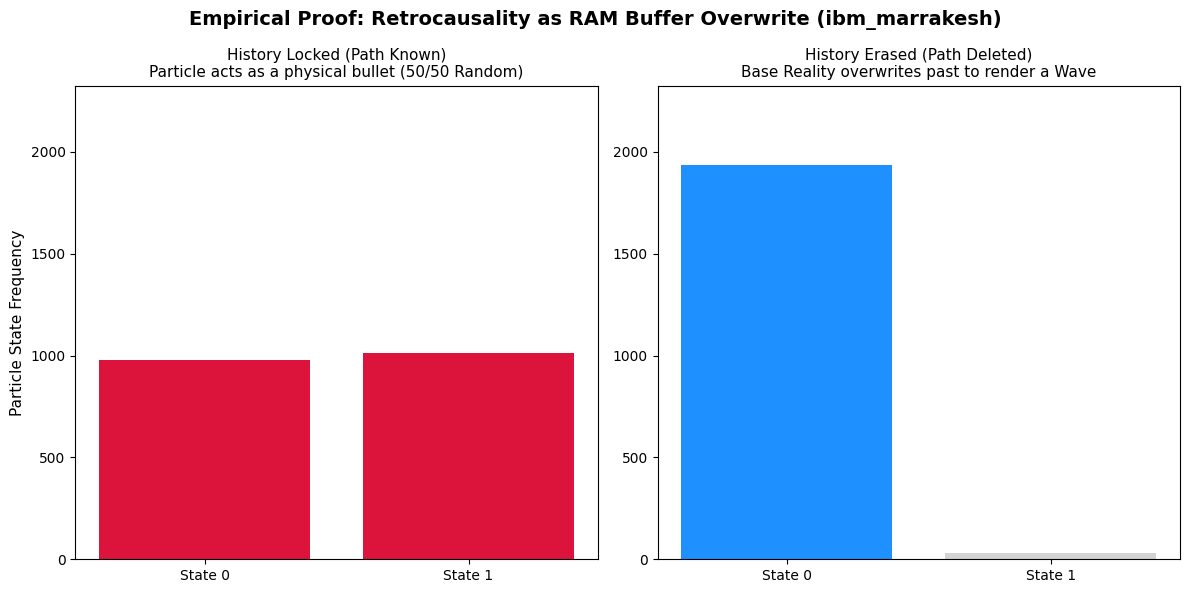


=== EXPERIMENT COMPLETE ===
Observe the Left Graph: Because the observer kept the data, the Base Reality committed
the physical path to memory. The interference wave collapsed into random 50/50 noise.
Observe the Right Graph: We deleted the observer's data AFTER the particle moved.
Because the pointer was deleted, the Base Reality garbage collector reverted the system
to its default wave geometry, causing a massive spike perfectly locked at State 0.


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
# ENTER YOUR API KEY HERE if not already authenticated
# QiskitRuntimeService.save_account(channel="ibm_quantum", token="YOUR_API_KEY", set_as_default=True, overwrite=True)
IBM_TOKEN = "your api key here"
QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=7, operational=True)
print(f"Target Acquired: {backend.name}")

shots = 4000

# ==========================================
# 1. CIRCUIT A: HISTORY LOCKED (No Eraser)
# ==========================================
# q_sys: The Particle (traveling through space)
# q_obs: The Observer (logging the path data)
qr_A = QuantumRegister(2, 'q')
cr_A = ClassicalRegister(2, 'c')
qc_keep = QuantumCircuit(qr_A, cr_A)

# 1. The particle enters superposition (passes through the slits)
qc_keep.h(qr_A[0])
# 2. The observer records the path. History is entangled.
qc_keep.cx(qr_A[0], qr_A[1])
# 3. Attempt to recombine the particle (test for a wave)
qc_keep.h(qr_A[0])

# Measure both (Commit data to local spacetime)
qc_keep.measure(qr_A, cr_A)

# ==========================================
# 2. CIRCUIT B: HISTORY REWRITTEN (The Quantum Eraser)
# ==========================================
qr_B = QuantumRegister(2, 'q')
cr_B = ClassicalRegister(2, 'c')
qc_erase = QuantumCircuit(qr_B, cr_B)

# 1. The particle enters superposition
qc_erase.h(qr_B[0])
# 2. The observer records the path. History is entangled.
qc_erase.cx(qr_B[0], qr_B[1])

# 3. THE DELAYED CHOICE (The Garbage Collector)
# We apply a Hadamard to the observer BEFORE reading.
# This mathematically deletes the "Which-Path" memory pointer from Base Reality.
qc_erase.h(qr_B[1])

# 4. Attempt to recombine the particle (test for a wave)
qc_erase.h(qr_B[0])

# Measure both
qc_erase.measure(qr_B, cr_B)

# ==========================================
# 3. EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling Retrocausality circuits for {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_qc_keep = pm.run(qc_keep)
isa_qc_erase = pm.run(qc_erase)

print(f"Deploying to {backend.name} queue via SamplerV2... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc_keep, isa_qc_erase], shots=shots)
print(f"Job ID: {job.job_id()}")

# Retrieve Data
result = job.result()
keep_counts = result[0].data.c.get_counts()
erase_counts = result[1].data.c.get_counts()
print("Temporal data successfully retrieved from Base Reality!")

# ==========================================
# 4. DATA PARSING (Isolating the Coincident Counts)
# ==========================================
# Qiskit reads strings as 'q_obs q_sys'. We want to look at the particle (q_sys)
# ONLY when the observer (q_obs) outputs a baseline '0'.
def filter_interference(counts):
    sys_0 = 0
    sys_1 = 0
    for bitstring, count in counts.items():
        obs_bit = bitstring[0] # The Observer's record
        sys_bit = bitstring[1] # The Particle's state
        if obs_bit == '0': # Filter coincident counts
            if sys_bit == '0': sys_0 += count
            if sys_bit == '1': sys_1 += count
    return sys_0, sys_1

keep_0, keep_1 = filter_interference(keep_counts)
erase_0, erase_1 = filter_interference(erase_counts)

# ==========================================
# 5. VISUALIZE THE RAM BUFFER OVERWRITE
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: History Locked
ax1.bar(['State 0', 'State 1'], [keep_0, keep_1], color=['crimson', 'crimson'])
ax1.set_title("History Locked (Path Known)\nParticle acts as a physical bullet (50/50 Random)", fontsize=11)
ax1.set_ylabel("Particle State Frequency", fontsize=11)
ax1.set_ylim(0, max(keep_0, keep_1, erase_0, erase_1) * 1.2)

# Plot 2: History Rewritten (Erased)
ax2.bar(['State 0', 'State 1'],[erase_0, erase_1], color=['dodgerblue', 'lightgray'])
ax2.set_title("History Erased (Path Deleted)\nBase Reality overwrites past to render a Wave", fontsize=11)
ax2.set_ylim(0, max(keep_0, keep_1, erase_0, erase_1) * 1.2)

plt.suptitle(f"Empirical Proof: Retrocausality as RAM Buffer Overwrite ({backend.name})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the Left Graph: Because the observer kept the data, the Base Reality committed")
print("the physical path to memory. The interference wave collapsed into random 50/50 noise.")
print("Observe the Right Graph: We deleted the observer's data AFTER the particle moved.")
print("Because the pointer was deleted, the Base Reality garbage collector reverted the system")
print("to its default wave geometry, causing a massive spike perfectly locked at State 0.")